# Gold Price Dynamics: Time Series Forecasting with LSTM

Proyek ini bertujuan untuk memprediksi harga emas (Gold/USD) menggunakan model **LSTM (Long Short-Term Memory)**, salah satu arsitektur deep learning yang populer untuk data time series.

## Alur Kerja
1. Load & eksplorasi dataset
2. Deteksi & handling outlier
3. Train/test split
4. Preprocessing (scaling & sliding window)
5. Membangun & melatih model LSTM
6. Evaluasi performa model
7. Prediksi harga emas 30 hari ke depan

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load Dataset

Dataset `GoldUSD.csv` berisi data harga emas harian (dalam USD) dari tahun 2000 hingga saat ini.

Kolom: **Date, Open, High, Low, Close, Volume**

Target prediksi: kolom **Close** (harga penutupan).

In [2]:
df = pd.read_csv("GoldUSD.csv")

# Konversi kolom Date dengan format yang benar untuk menghindari warning
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%y")

# Target kolom yang akan diprediksi
TARGET_COL = "Close"

print(f"Dataset shape: {df.shape}")
print(f"Rentang tanggal: {df['Date'].min()} - {df['Date'].max()}")

Dataset shape: (6399, 6)
Rentang tanggal: 2000-08-30 00:00:00 - 2026-03-03 00:00:00


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("=== 5 Data Teratas ===")
print(df.head())
print()

print("=== Tipe Data ===")
print(df.dtypes)
print()

print("=== Missing Values ===")
print(df.isnull().sum())
print()

print("=== Statistik Deskriptif ===")
print(df.describe())

=== 5 Data Teratas ===
        Date        Open        High         Low       Close  Volume
0 2000-08-30  273.899994  273.899994  273.899994  273.899994       0
1 2000-08-31  274.799988  278.299988  274.799988  278.299988       0
2 2000-09-01  277.000000  277.000000  277.000000  277.000000       0
3 2000-09-05  275.799988  275.799988  275.799988  275.799988       2
4 2000-09-06  274.200012  274.200012  274.200012  274.200012       0

=== Tipe Data ===
Date      datetime64[us]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

=== Missing Values ===
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

=== Statistik Deskriptif ===
                             Date         Open         High          Low  \
count                        6399  6399.000000  6399.000000  6399.000000   
mean   2013-06-08 07:45:49.367088  1274.892437  1281.728724  1267.908032   
min          

## 4. Deteksi Outlier

Menggunakan metode **IQR (Interquartile Range)** untuk mendeteksi outlier pada kolom numerik.

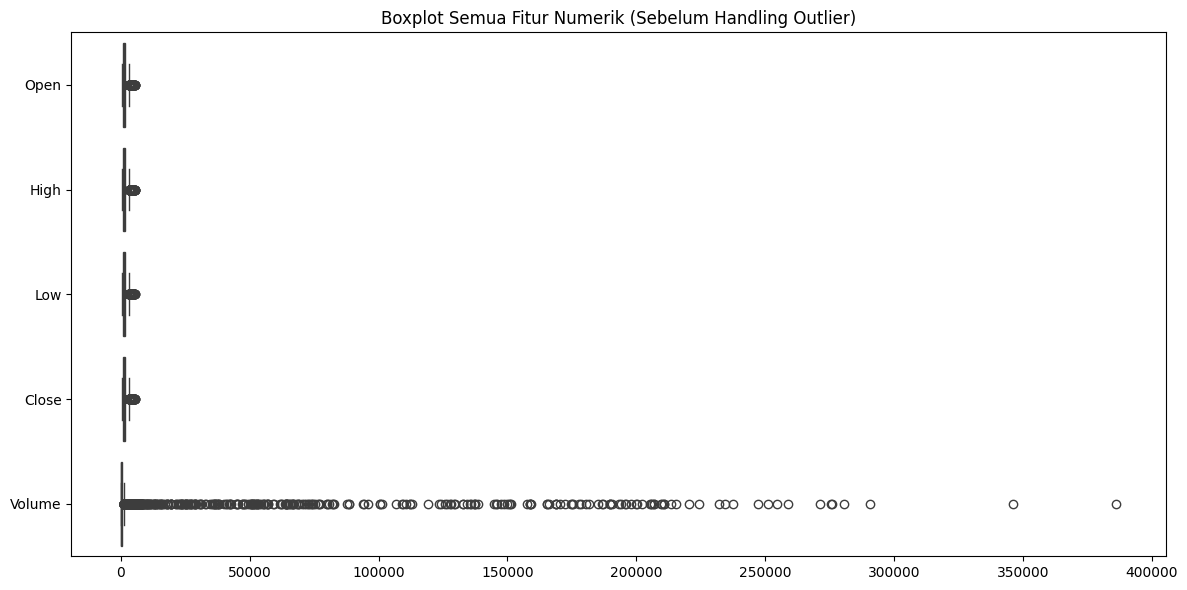


Jumlah outlier per kolom sebelum handling:
  Open: 54
  High: 55
  Low: 53
  Close: 53
  Volume: 661


In [4]:
num_cols = df.select_dtypes(include="number").columns

# Konversi ke numerik (handle nilai yang tidak valid)
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Isi NaN dengan median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Visualisasi boxplot sebelum handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

# Hitung jumlah outlier per kolom
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 2.5 * IQR
    upper = Q3 + 2.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

print("\nJumlah outlier per kolom sebelum handling:")
for k, v in outlier_summary.items():
    print(f"  {k}: {v}")

## 5. Train/Test Split

Data dibagi menjadi **80% training** dan **20% testing**.

> **Penting:** Split dilakukan **sebelum** outlier handling untuk menghindari *data leakage*.

In [5]:
# Ambil data target (Close price)
data = df[[TARGET_COL]].values

TRAIN_RATIO = 0.8
train_size = int(len(data) * TRAIN_RATIO)

# Bagi data
train_data_raw = data[:train_size]
test_data_raw = data[train_size:]

print(f"Training samples : {len(train_data_raw)}")
print(f"Test samples     : {len(test_data_raw)}")

Training samples : 5119
Test samples     : 1280


## 6. Handling Outlier (Tanpa Data Leakage)

Outlier di-handle menggunakan metode **clipping** berdasarkan IQR.

> **Best Practice:** Batas outlier (lower/upper) dihitung **hanya dari data training**, lalu diterapkan ke data training dan test. Ini mencegah informasi dari data test "bocor" ke proses pelatihan model.

In [6]:
# Hitung IQR dari training data SAJA
train_series = pd.Series(train_data_raw.flatten())
Q1 = train_series.quantile(0.25)
Q3 = train_series.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 2.0 * IQR
upper_bound = Q3 + 2.0 * IQR

# Terapkan clipping ke kedua set data
train_data = np.clip(train_data_raw, lower_bound, upper_bound)
test_data = np.clip(test_data_raw, lower_bound, upper_bound)

print(f"Outlier bounds (dari training data): [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Training outliers clipped : {((train_data_raw < lower_bound) | (train_data_raw > upper_bound)).sum()}")
print(f"Test outliers clipped     : {((test_data_raw < lower_bound) | (test_data_raw > upper_bound)).sum()}")

Outlier bounds (dari training data): [-1240.95, 3032.05]
Training outliers clipped : 0
Test outliers clipped     : 235


## 7. Feature Scaling

Menggunakan **StandardScaler** (z-score normalization).

> **Best Practice:** `fit_transform()` hanya pada data training, lalu `transform()` pada data test.

In [7]:
scaler = StandardScaler()

# Fit hanya pada training data
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(f"Train scaled - mean: {train_scaled.mean():.4f}, std: {train_scaled.std():.4f}")
print(f"Test scaled  - mean: {test_scaled.mean():.4f}, std: {test_scaled.std():.4f}")

Train scaled - mean: 0.0000, std: 1.0000
Test scaled  - mean: 2.5261, std: 1.0213


## 8. Sliding Window

Membuat sequence data dengan **window size = 30**, artinya model melihat 30 hari ke belakang untuk memprediksi harga 1 hari ke depan.

In [8]:
WINDOW_SIZE = 30

def create_window(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_train, y_train = create_window(train_scaled, WINDOW_SIZE)
X_test, y_test = create_window(test_scaled, WINDOW_SIZE)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape: (5089, 30, 1)
y_train shape: (5089, 1)
X_test shape : (1250, 30, 1)
y_test shape : (1250, 1)


## 9. Arsitektur Model LSTM

Model terdiri dari:
- **LSTM** layer dengan 64 unit
- **Dropout** (0.3) untuk mencegah overfitting
- **Dense** layer (1 output) untuk prediksi harga

In [9]:
model = Sequential([
    LSTM(64, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.3),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

C:\Users\ibnua\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Training Model

Model dilatih dengan:
- **Epochs:** max 50 (dengan Early Stopping)
- **Batch size:** 32
- **Early Stopping:** Menghentikan training jika validation loss tidak membaik selama 5 epoch berturut-turut, dan mengembalikan bobot terbaik.

In [10]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50


  1/160 ━━━━━━━━━━━━━━━━━━━━ 3:29 1s/step - loss: 0.8703

  9/160 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6955 

 18/160 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5440

 27/160 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4520

...

142/160 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0096

152/160 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0096

160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0090 - val_loss: 0.0481


Epoch 12: early stopping


Restoring model weights from the end of the best epoch: 7.


## 11. Visualisasi Training vs Validation Loss

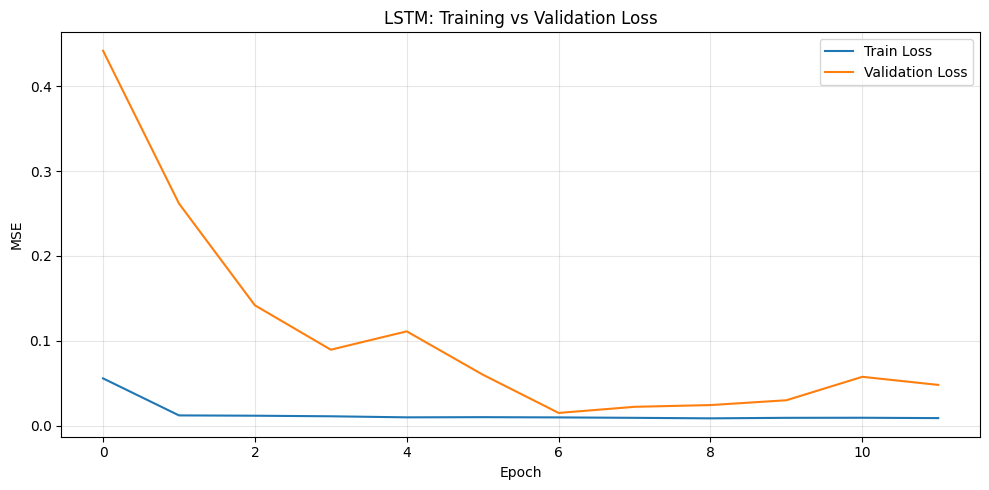

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("LSTM: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Evaluasi Model

Mengevaluasi performa model pada test set menggunakan metrik:
- **MAE** (Mean Absolute Error): Rata-rata kesalahan absolut
- **RMSE** (Root Mean Squared Error): Akar rata-rata kuadrat kesalahan
- **MAPE** (Mean Absolute Percentage Error): Rata-rata persentase kesalahan

In [12]:
# Prediksi pada test set
y_pred_scaled = model.predict(X_test)

# Inverse transform ke skala asli
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# Hitung metrik evaluasi
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print("=" * 40)
print("    EVALUATION METRICS (Test Set)")
print("=" * 40)
print(f"  MAE  : ${mae:.2f}")
print(f"  RMSE : ${rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)

 1/40 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step

24/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


    EVALUATION METRICS (Test Set)
  MAE  : $43.51
  RMSE : $59.02
  MAPE : 1.75%


## 13. Visualisasi: Actual vs Predicted (Test Set)

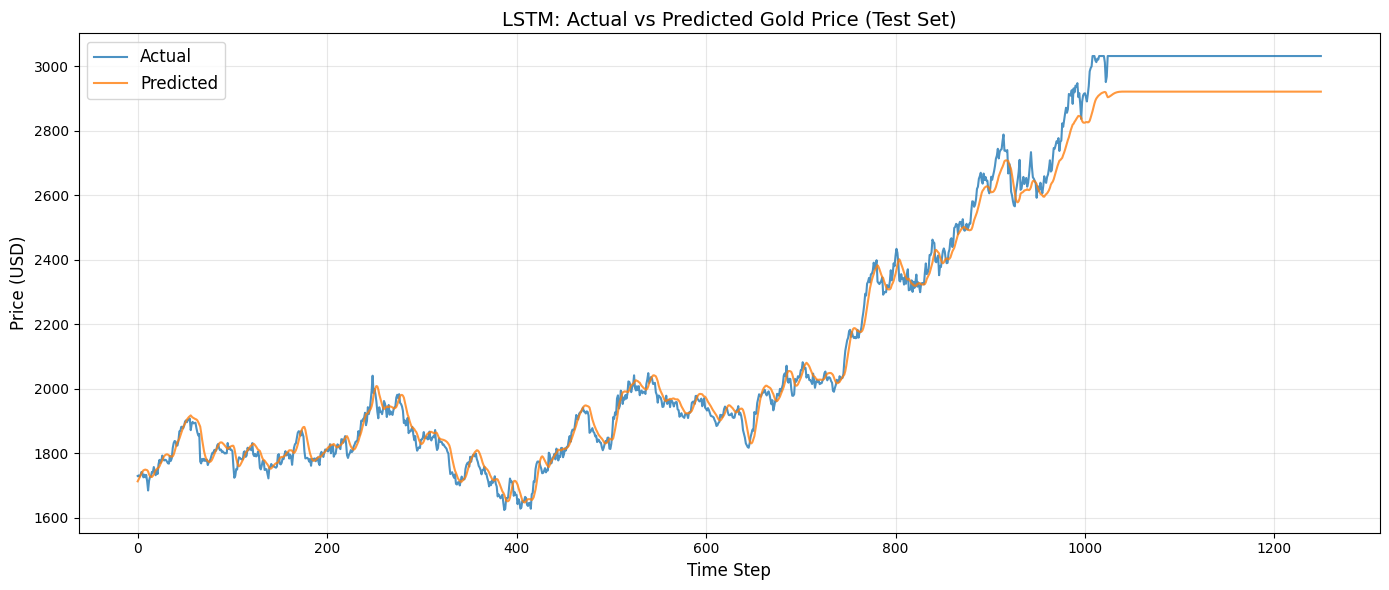

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(y_actual, label="Actual", alpha=0.8, linewidth=1.5)
plt.plot(y_pred, label="Predicted", alpha=0.8, linewidth=1.5)
plt.legend(fontsize=12)
plt.title("LSTM: Actual vs Predicted Gold Price (Test Set)", fontsize=14)
plt.xlabel("Time Step", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Prediksi Harga Emas 30 Hari ke Depan

Menggunakan teknik **recursive forecasting**: model memprediksi 1 hari ke depan, lalu hasil prediksi dimasukkan kembali ke window untuk memprediksi hari berikutnya.

In [14]:
FUTURE_DAYS = 30

# Ambil window terakhir dari data test yang sudah di-scale
last_window = test_scaled[-WINDOW_SIZE:]
current_window = last_window.reshape(1, WINDOW_SIZE, 1)

future_predictions = []
for _ in range(FUTURE_DAYS):
    next_pred = model.predict(current_window, verbose=0)
    future_predictions.append(next_pred[0, 0])

    # Geser window: buang hari pertama, tambahkan prediksi di akhir
    current_window = np.append(
        current_window[:, 1:, :],
        [[[next_pred[0, 0]]]],
        axis=1
    )

# Inverse transform ke skala asli
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

print(f"Prediksi {FUTURE_DAYS} hari ke depan:")
for i, pred in enumerate(future_predictions):
    print(f"  Hari {i+1}: ${pred[0]:.2f}")

Prediksi 30 hari ke depan:
  Hari 1: $2921.55
  Hari 2: $2910.32
  Hari 3: $2896.88
  Hari 4: $2882.65
  Hari 5: $2867.89
  Hari 6: $2852.97
  Hari 7: $2838.16
  Hari 8: $2823.63
  Hari 9: $2809.48
  Hari 10: $2795.78
  Hari 11: $2782.55
  Hari 12: $2769.80
  Hari 13: $2757.54
  Hari 14: $2745.74
  Hari 15: $2734.39
  Hari 16: $2723.48
  Hari 17: $2712.99
  Hari 18: $2702.89
  Hari 19: $2693.17
  Hari 20: $2683.80
  Hari 21: $2674.77
  Hari 22: $2666.06
  Hari 23: $2657.66
  Hari 24: $2649.55
  Hari 25: $2641.72
  Hari 26: $2634.15
  Hari 27: $2626.83
  Hari 28: $2619.74
  Hari 29: $2612.89
  Hari 30: $2606.25


## 15. Visualisasi: Historical & Forecast

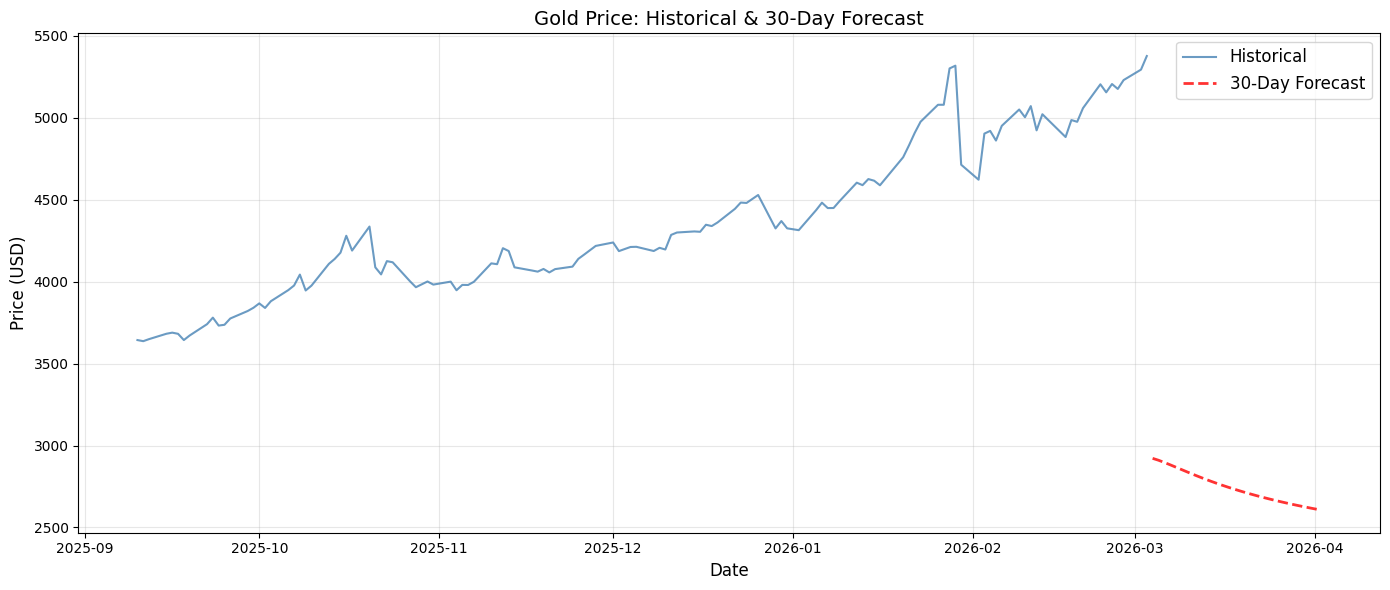

In [15]:
# Generate tanggal untuk prediksi masa depan
last_date = df["Date"].iloc[-1]
future_dates = pd.date_range(
    start=last_date,
    periods=FUTURE_DAYS + 1,
    freq="D"
)[1:]

# Plot 120 hari terakhir + prediksi 30 hari
plt.figure(figsize=(14, 6))

# Data historis (120 hari terakhir)
hist_dates = df["Date"].values[-120:]
hist_prices = df[TARGET_COL].values[-120:]
plt.plot(hist_dates, hist_prices, label="Historical", alpha=0.8, linewidth=1.5, color="steelblue")

# Prediksi masa depan
plt.plot(future_dates, future_predictions, label=f"{FUTURE_DAYS}-Day Forecast",
         color="red", linestyle="--", alpha=0.8, linewidth=2)

plt.legend(fontsize=12)
plt.title(f"Gold Price: Historical & {FUTURE_DAYS}-Day Forecast", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Kesimpulan

Dalam proyek ini, kita telah:

1. **Mengeksplorasi** dataset harga emas (Gold/USD) yang mencakup data dari tahun 2000 hingga saat ini
2. **Mendeteksi dan menangani outlier** menggunakan metode IQR dengan strategi clipping, dengan menghindari data leakage
3. **Membangun model LSTM** untuk memprediksi harga penutupan (Close price) berdasarkan 30 hari data historis
4. **Melatih model** dengan Early Stopping untuk mencegah overfitting
5. **Mengevaluasi performa** model menggunakan MAE, RMSE, dan MAPE pada test set
6. **Memprediksi** harga emas 30 hari ke depan menggunakan recursive forecasting

### Potensi Improvement
- Menambahkan lebih banyak fitur (Open, High, Low, Volume) sebagai input
- Eksperimen dengan arsitektur lain (GRU, Bidirectional LSTM, Transformer)
- Hyperparameter tuning (window size, jumlah unit, learning rate)
- Cross-validation untuk time series (walk-forward validation)